In [78]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    ExtraTreesClassifier,
    RandomForestRegressor,
    AdaBoostRegressor
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    classification_report,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder , PowerTransformer
from sklearn.impute import SimpleImputer

In [79]:
df_train = pd.read_csv('Projects/Irregation Prediction/train.csv')
df_test = pd.read_csv('Projects/Irregation Prediction/train.csv')

In [80]:
print(df_train['Irrigation_Need'].value_counts(normalize=True))

Irrigation_Need
Low       0.587170
Medium    0.379483
High      0.033348
Name: proportion, dtype: float64


In [81]:
len(df_train.columns)

21

In [82]:
cat_columns = df_train.select_dtypes(include=['category','object','str']).columns.tolist()
numeric_cols = df_train.select_dtypes(include='number').columns.tolist()

In [83]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  str    
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  str    
 12  Crop_Growth_Stage        630000 non-null  str    
 13  Season                   630000 non-null  str    
 14  Irrigation_Type

In [84]:
df_train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [85]:
df_test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [86]:
test_ids = df_test['id'].values

In [87]:
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_train['Irrigation_Need'] = df_train['Irrigation_Need'].map(target_mapping)
df_test['Irrigation_Need'] = df_test['Irrigation_Need'].map(target_mapping)

In [88]:
df_train_encoded = pd.get_dummies(df_train,drop_first=True)
df_test_encoded = pd.get_dummies(df_test,drop_first=True)

In [89]:
df_train_encoded.columns

Index(['id', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare',
       'Previous_Irrigation_mm', 'Irrigation_Need', 'Soil_Type_Loamy',
       'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Type_Maize',
       'Crop_Type_Potato', 'Crop_Type_Rice', 'Crop_Type_Sugarcane',
       'Crop_Type_Wheat', 'Crop_Growth_Stage_Harvest',
       'Crop_Growth_Stage_Sowing', 'Crop_Growth_Stage_Vegetative',
       'Season_Rabi', 'Season_Zaid', 'Irrigation_Type_Drip',
       'Irrigation_Type_Rainfed', 'Irrigation_Type_Sprinkler',
       'Water_Source_Rainwater', 'Water_Source_Reservoir',
       'Water_Source_River', 'Mulching_Used_Yes', 'Region_East',
       'Region_North', 'Region_South', 'Region_West'],
      dtype='str')

In [90]:
X_train = df_train_encoded.drop(columns='Irrigation_Need').values
X_test = df_test_encoded.drop(columns='Irrigation_Need').values

Y_train = df_train_encoded['Irrigation_Need'].values
Y_test = df_test_encoded['Irrigation_Need'].values


print(X_train.shape)
print(Y_train.shape)


(630000, 36)
(630000,)


In [91]:
import optuna
import xgboost as xgb

print(X_train.shape)
print(Y_train.shape)
df_DMatrix = xgb.DMatrix(data=X_train,label=Y_train)

def objective(trial):

    params = {
        "objective": "multi:softmax",
        "num_class": 3,
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "eta": trial.suggest_float("eta", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "eval_metric": "mlogloss",
        "nthread": -1
    }

    cv = xgb.cv(
        params,
        df_DMatrix,
        nfold=4,
        num_boost_round=30,
        early_stopping_rounds=10
    )

    return cv["test-mlogloss-mean"].min()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=4)

print(study.best_params)

(630000, 36)
(630000,)


[I 2026-04-08 13:14:27,721] A new study created in memory with name: no-name-ff7de785-f8cc-4a1e-8fd5-466c1694211b
[I 2026-04-08 13:14:43,444] Trial 0 finished with value: 0.0881839436365115 and parameters: {'max_depth': 4, 'eta': 0.21520814964492338, 'subsample': 0.8215172250616316, 'colsample_bytree': 0.8954386333459357}. Best is trial 0 with value: 0.0881839436365115.
[I 2026-04-08 13:15:00,109] Trial 1 finished with value: 0.0829650845017619 and parameters: {'max_depth': 4, 'eta': 0.24612919866200655, 'subsample': 0.9611019697132916, 'colsample_bytree': 0.8182459143529947}. Best is trial 1 with value: 0.0829650845017619.
[I 2026-04-08 13:15:19,110] Trial 2 finished with value: 0.061722904808654416 and parameters: {'max_depth': 7, 'eta': 0.27287825344550987, 'subsample': 0.725747276839269, 'colsample_bytree': 0.9420254610506509}. Best is trial 2 with value: 0.061722904808654416.
[I 2026-04-08 13:15:42,451] Trial 3 finished with value: 0.06139099718155369 and parameters: {'max_depth':

{'max_depth': 8, 'eta': 0.27582947688888826, 'subsample': 0.9067838722359329, 'colsample_bytree': 0.9106658870280229}


In [92]:
model = xgb.XGBClassifier(study.best_params)

model.fit(X_train, Y_train)

preds = model.predict(X_test)

print(classification_report(Y_test, preds))

/Users/apple/Documents Local/Mubashir Code/ML/.venv/lib/python3.12/site-packages/xgboost/core.py:748: FutureWarning: Pass `objective` as keyword args.
  warnings.warn(msg, FutureWarning)


              precision    recall  f1-score   support

           0       0.99      1.00      0.99    369917
           1       0.99      0.98      0.98    239074
           2       0.98      0.94      0.96     21009

    accuracy                           0.99    630000
   macro avg       0.98      0.97      0.98    630000
weighted avg       0.99      0.99      0.99    630000



In [93]:
print(model.feature_importances_)

[0.00087532 0.00096004 0.09952466 0.0009626  0.00100483 0.05721972
 0.00147046 0.01831382 0.00098269 0.05628557 0.00096367 0.00147183
 0.00082422 0.00096079 0.00095249 0.00094527 0.00096169 0.00117655
 0.00096021 0.00084308 0.23586352 0.34014767 0.00741126 0.00085593
 0.00081106 0.00111088 0.00092971 0.00098119 0.0007841  0.00153162
 0.00105817 0.15730897 0.00085537 0.0009928  0.00086662 0.00083163]


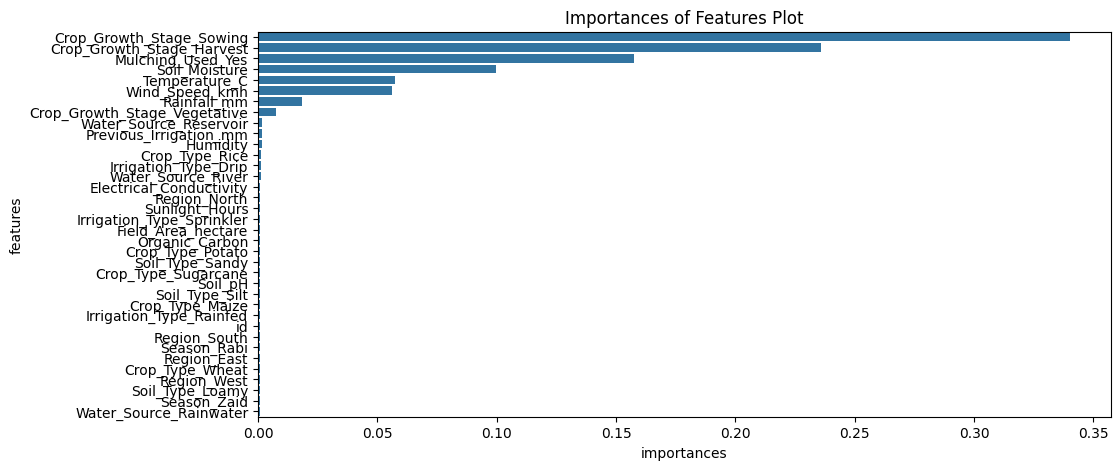

In [94]:
df_plot = pd.DataFrame({'features': df_train_encoded.columns[df_train_encoded.columns != 'Irrigation_Need'],
                        'importances': model.feature_importances_})
df_plot = df_plot.sort_values('importances', ascending=False)
plt.figure(figsize=[11,5])
sns.barplot(x = df_plot.importances, y = df_plot.features)
plt.title('Importances of Features Plot')
plt.show()

In [2]:
submission = pd.DataFrame({'id': test_ids, 'Irrigation_Need': pred})

NameError: name 'pd' is not defined